# Time Series Models - From ARMA to Modern Forecasting

The previous notebook (`TimeSeries.ipynb`) introduced the ideas of trend, seasonality, stationarity, autocorrelation, and the simple workflow of forecasting. This notebook is the next step: a tour of the actual models that practitioners use.

We will start with the classical statistical family - AR, MA, ARMA, ARIMA, SARIMA, SARIMAX - and derive each one in a simplified form. Then we will look at modern neural approaches - N-BEATS and the Temporal Fusion Transformer - at a conceptual level, with a small NumPy demonstration of the N-BEATS basis idea. We will close with hierarchical forecasting and reconciliation.

The running example throughout this notebook is a **synthetic stock-like dataset**, with daily price and volume that look very similar to a real equity. We will compute a few common technical indicators (simple and exponential moving averages, RSI, log returns, on-balance volume) and use both the price and the indicators when we fit models.

This is a long notebook. Treat it as a reference; you are not expected to absorb every formula on the first read.


## Setup

We will use:

- `numpy`, `pandas`, `matplotlib` for data and plots.
- `statsmodels` for the classical models (ARIMA, SARIMA, SARIMAX).
- The **Nixtla** ecosystem for the more complex models, which gives us a uniform interface and saves a lot of glue code:
  - `statsforecast` for fast classical forecasting (AutoARIMA, AutoETS).
  - `neuralforecast` for **N-BEATS** and the **Temporal Fusion Transformer (TFT)**.
  - `hierarchicalforecast` for hierarchical reconciliation.

If anything is missing, install with:

```
pip install statsmodels statsforecast neuralforecast hierarchicalforecast utilsforecast
```

In [1]:
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning_fabric").setLevel(logging.ERROR)
os.environ["PYTORCH_LIGHTNING_VERBOSITY"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Classical statistical models
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Nixtla ecosystem - one consistent API across statistical, neural, and hierarchical models
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, TFT
from neuralforecast.losses.pytorch import MAE, MQLoss

from hierarchicalforecast.core   import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, TopDown, MinTrace
from hierarchicalforecast.utils  import aggregate

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

rng = np.random.default_rng(42)

print("Libraries loaded.")

2026-05-03 09:35:43,415	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-03 09:35:43,589	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Libraries loaded.


## 1. A synthetic stock-like dataset

Real intraday equity data has several features that make it interesting for time-series modelling:

- A long-term trend (companies grow or shrink over years).
- A weekly seasonal effect on volume (e.g. Mondays and Fridays are different).
- Volatility that clusters - a calm week is often followed by a calm week, a turbulent week by another turbulent week.
- A relationship between price and volume (sharp moves come with heavier volume).

We will generate a two-year daily series that exhibits all of these. Working with synthetic data lets us know the true structure, which is invaluable when learning.


In [2]:
# Two years of business-day timestamps.
dates = pd.bdate_range(start="2024-01-01", end="2025-12-31")
T = len(dates)

# Geometric Brownian motion-like log-returns with volatility clustering.
# A simple GARCH-style innovation: today's volatility depends on yesterday's shock.
sigma = np.zeros(T)
shock = np.zeros(T)
sigma[0] = 0.012
for t in range(1, T):
    sigma[t] = np.sqrt(0.00002 + 0.10 * shock[t-1]**2 + 0.85 * sigma[t-1]**2)
    shock[t] = sigma[t] * rng.standard_normal()

# Drift component (a small upward trend) plus the volatility shock.
mu = 0.0006
log_ret = mu + shock

# Build the price by exponentiating cumulative log returns.
price = 100 * np.exp(np.cumsum(log_ret))

# Volume: weekly seasonality (heavier on Mondays and Fridays) + reaction to large moves.
day_of_week = pd.Series(dates).dt.dayofweek.values   # 0 = Monday
weekly = np.array([1.20, 0.95, 0.90, 0.95, 1.15])[day_of_week]
volume = (1_000_000 * weekly *
          (1 + 4 * np.abs(log_ret)) *
          rng.lognormal(mean=0.0, sigma=0.15, size=T)).astype(int)

stock = pd.DataFrame(
    {"close": price, "log_return": log_ret, "volume": volume},
    index=dates,
)
stock.index.name = "date"

print(stock.head())
print(f"\nRows: {len(stock)}")
print(f"Date range: {stock.index.min().date()} to {stock.index.max().date()}")


                 close  log_return   volume
date                                       
2024-01-01  100.060018    0.000600  1469741
2024-01-02  100.484795    0.004236   938763
2024-01-03   99.305185   -0.011809  1163421
2024-01-04  100.301744    0.009985   924493
2024-01-05  101.569712    0.012562  1502373

Rows: 523
Date range: 2024-01-01 to 2025-12-31


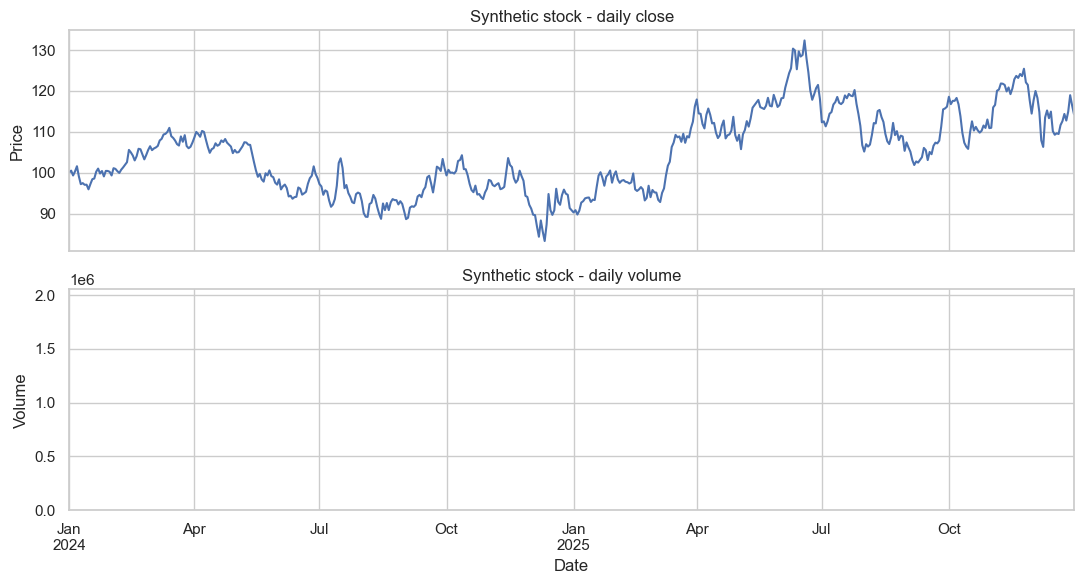

In [3]:
# A quick look at the price and volume.
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
stock["close"].plot(ax=axes[0], color="#4C72B0")
axes[0].set_title("Synthetic stock - daily close")
axes[0].set_ylabel("Price")

axes[1].bar(stock.index, stock["volume"], color="#DD8452", alpha=0.7, width=1.0)
axes[1].set_title("Synthetic stock - daily volume")
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()


## 2. Adding technical indicators

Most practitioners do not feed raw prices into a model. They first compute a handful of *indicators* that summarise level, trend, and momentum. We will compute four classic ones:

| Indicator | What it measures | Formula |
|-----------|------------------|---------|
| Simple moving average (SMA-20) | Average price of the last 20 days. | `SMA_t = mean(close[t-19 .. t])` |
| Exponential moving average (EMA-20) | A smoothed price that weights recent days more. | `EMA_t = alpha * close_t + (1 - alpha) * EMA_{t-1}` with `alpha = 2 / (n + 1)` |
| Relative Strength Index (RSI-14) | Momentum: how much the recent gains dominate the recent losses, on a 0-100 scale. | See code below. |
| On-Balance Volume (OBV) | Cumulative volume, signed by whether price went up or down that day. | `OBV_t = OBV_{t-1} + sign(close_t - close_{t-1}) * volume_t` |

These will become useful when we fit the SARIMAX model later (X = exogenous variables).


In [4]:
def rsi(series, n=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.rolling(n).mean()
    avg_loss = loss.rolling(n).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


stock["sma_20"] = stock["close"].rolling(20).mean()
stock["ema_20"] = stock["close"].ewm(span=20, adjust=False).mean()
stock["rsi_14"] = rsi(stock["close"], 14)
stock["obv"]    = (np.sign(stock["close"].diff()).fillna(0) * stock["volume"]).cumsum()

print(stock[["close", "sma_20", "ema_20", "rsi_14", "obv"]].dropna().head())


                 close     sma_20     ema_20     rsi_14        obv
date                                                              
2024-01-26  100.423124  99.024360  99.303461  55.117948  5741066.0
2024-01-29  100.409041  99.041811  99.408754  64.162173  4494950.0
2024-01-30  100.202497  99.027696  99.484349  62.181801  3562533.0
2024-01-31   99.309964  99.027935  99.467741  59.676272  2665089.0
2024-02-01  101.085905  99.067143  99.621852  64.853642  3658438.0


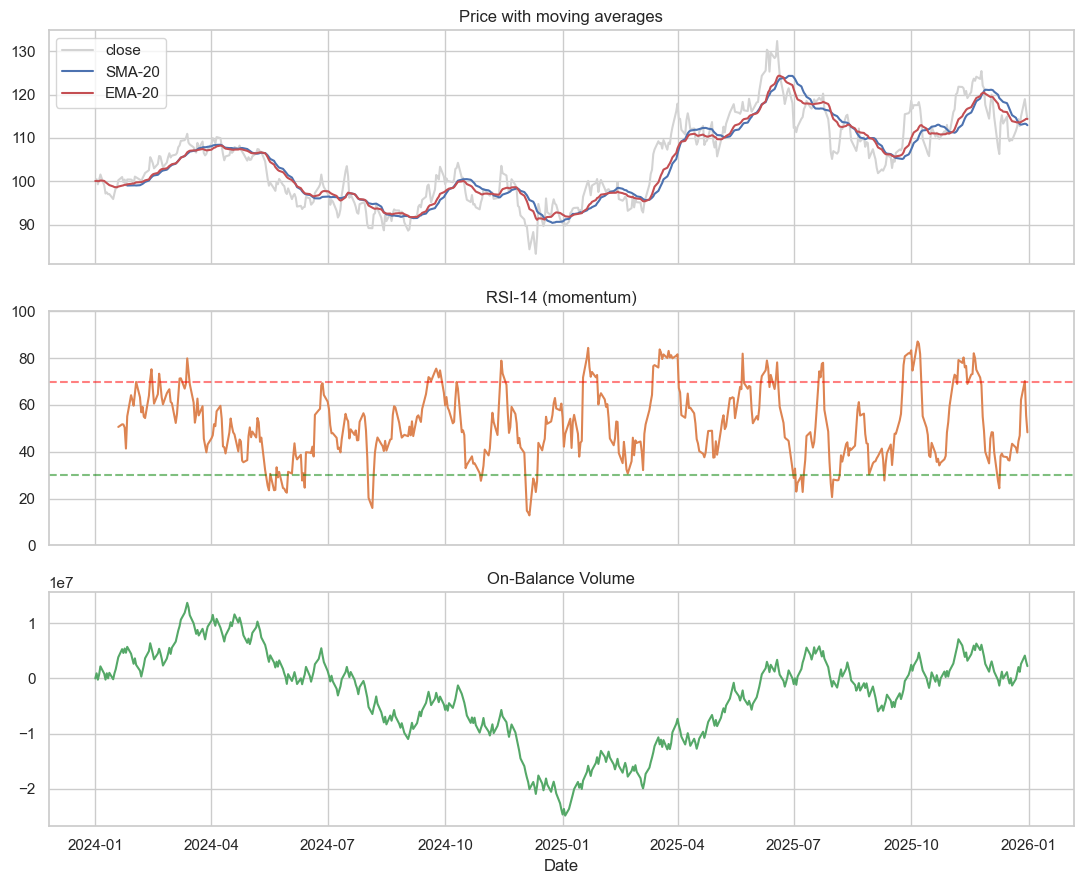

In [5]:
# Quick visual of the indicators.
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(stock.index, stock["close"],  color="lightgrey", label="close")
axes[0].plot(stock.index, stock["sma_20"], color="#4C72B0",   label="SMA-20")
axes[0].plot(stock.index, stock["ema_20"], color="#C44E52",   label="EMA-20")
axes[0].set_title("Price with moving averages")
axes[0].legend(loc="upper left")

axes[1].plot(stock.index, stock["rsi_14"], color="#DD8452")
axes[1].axhline(70, color="red",   linestyle="--", alpha=0.5)
axes[1].axhline(30, color="green", linestyle="--", alpha=0.5)
axes[1].set_title("RSI-14 (momentum)")
axes[1].set_ylim(0, 100)

axes[2].plot(stock.index, stock["obv"], color="#55A868")
axes[2].set_title("On-Balance Volume")
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()


## 3. AR and MA - the building blocks

Every model in this section is built out of two ideas: regressing on past values (AR), and regressing on past errors (MA).

### 3.1 The autoregressive model AR(p)

An AR(p) model says today's value is a linear combination of the previous p values, plus a random shock:

$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \varepsilon_t
$$

where $\varepsilon_t$ is white noise (mean zero, constant variance, independent across time).

**Reading the equation.** "Today is some constant plus a weighted sum of recent past, plus a random surprise." The weights $\phi_i$ are the parameters we estimate.

### 3.2 The moving-average model MA(q)

An MA(q) model says today's value is a linear combination of the previous q random shocks:

$$
y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q}
$$

The shocks $\varepsilon_t$ are unobserved; we only see $y_t$. Even so, the parameters $\theta_i$ can be estimated by maximum likelihood.

### 3.3 Why both?

- AR captures *persistence*: trends, momentum, mean-reverting behaviour.
- MA captures the lingering effect of past *shocks* that are no longer fully visible.

Real series usually need a bit of each, which is exactly what ARMA combines.


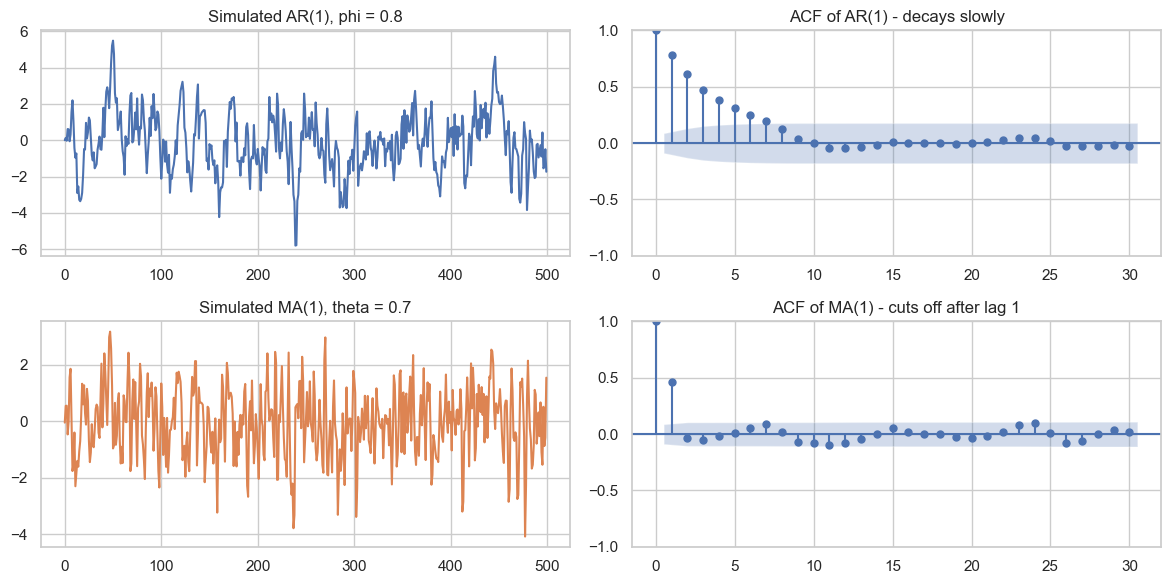

In [6]:
# Generate two clean simulated series to illustrate.
def simulate_ar1(phi, n=500, sigma=1.0, seed=0):
    g = np.random.default_rng(seed)
    y = np.zeros(n)
    for t in range(1, n):
        y[t] = phi * y[t-1] + g.normal(0, sigma)
    return y

def simulate_ma1(theta, n=500, sigma=1.0, seed=0):
    g = np.random.default_rng(seed)
    eps = g.normal(0, sigma, size=n+1)
    return eps[1:] + theta * eps[:-1]

ar1 = simulate_ar1(phi=0.8)
ma1 = simulate_ma1(theta=0.7)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes[0, 0].plot(ar1, color="#4C72B0"); axes[0, 0].set_title("Simulated AR(1), phi = 0.8")
plot_acf(ar1, ax=axes[0, 1], lags=30, title="ACF of AR(1) - decays slowly")

axes[1, 0].plot(ma1, color="#DD8452"); axes[1, 0].set_title("Simulated MA(1), theta = 0.7")
plot_acf(ma1, ax=axes[1, 1], lags=30, title="ACF of MA(1) - cuts off after lag 1")

plt.tight_layout()
plt.show()


Two important visual rules of thumb:

- The **ACF of an MA(q)** cuts off sharply after lag q.
- The **PACF of an AR(p)** cuts off sharply after lag p.

These two facts are the basis of the classical "Box-Jenkins" approach for choosing model orders.


## 4. ARMA(p, q) - combining AR and MA

The ARMA(p, q) model puts the two pieces together:

$$
y_t = c + \sum_{i=1}^{p} \phi_i\, y_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j\, \varepsilon_{t-j}
$$

Or, using the **lag operator** $L$ where $L y_t = y_{t-1}$, it can be written compactly as

$$
\Phi(L)\, y_t = \Theta(L)\, \varepsilon_t,
$$

with $\Phi(L) = 1 - \phi_1 L - \dots - \phi_p L^p$ and $\Theta(L) = 1 + \theta_1 L + \dots + \theta_q L^q$.

**Stationarity requirement.** ARMA assumes the series is already stationary. If it has a trend or growing variance, ARMA is the wrong tool - which is exactly what ARIMA fixes.


## 5. ARIMA(p, d, q) - adding differencing

The "I" in ARIMA stands for *integrated*. It means we difference the series d times before we apply ARMA:

$$
\nabla^d y_t = (1 - L)^d y_t.
$$

So ARIMA(p, d, q) is just ARMA(p, q) applied to the d-times differenced series:

$$
\Phi(L)\, (1 - L)^d\, y_t = \Theta(L)\, \varepsilon_t.
$$

Choosing d:

- d = 0: the original series is already stationary.
- d = 1: a single difference removes a linear trend.
- d = 2: rarely needed; two differences remove a quadratic trend.

In practice you almost always pick d using the ADF test (see `TimeSeries.ipynb`).

We will fit an ARIMA model to our stock's **log returns** rather than the raw price, because returns are much closer to stationary.


In [7]:
returns = stock["log_return"].dropna()

print("ADF test on log returns:")
stat, p, *_ = adfuller(returns)
print(f"  ADF stat = {stat:.3f},  p-value = {p:.4f}")
print("Returns are already stationary, so we will use d = 0.")

# Fit ARIMA(p=2, d=0, q=2) - a small, illustrative order.
arima_model = ARIMA(returns, order=(2, 0, 2)).fit()
print(arima_model.summary().tables[1])


ADF test on log returns:
  ADF stat = -16.627,  p-value = 0.0000
Returns are already stationary, so we will use d = 0.
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.001      0.425      0.671      -0.001       0.001
ar.L1          0.7303      0.279      2.614      0.009       0.183       1.278
ar.L2          0.0310      0.287      0.108      0.914      -0.532       0.594
ma.L1         -0.6480      0.287     -2.257      0.024      -1.211      -0.085
ma.L2         -0.1750      0.291     -0.601      0.548      -0.745       0.395
sigma2         0.0003   1.79e-05     18.173      0.000       0.000       0.000


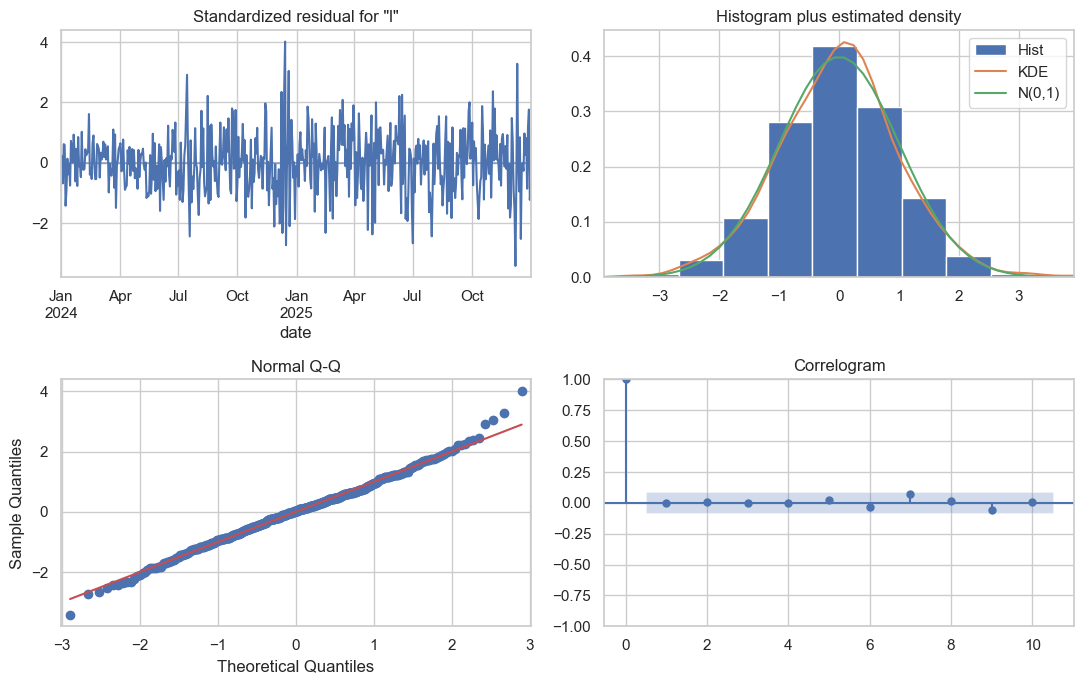

In [8]:
# Diagnostic plots.
arima_model.plot_diagnostics(figsize=(11, 7))
plt.tight_layout()
plt.show()


How to read an ARIMA diagnostic panel:

- **Top-left (residuals over time):** should look like noise around zero.
- **Top-right (histogram and KDE):** should be roughly bell-shaped.
- **Bottom-left (Q-Q plot):** points should sit on the red line if residuals are Normal.
- **Bottom-right (correlogram):** should show no significant bars - the model has captured the autocorrelation.

If any of these look wrong, increase or decrease p or q and try again.


## 6. SARIMA(p, d, q)(P, D, Q, s) - adding seasonality

Many series repeat at a fixed period s: weekly (s = 7 for daily data), monthly (s = 12 for monthly data), yearly. SARIMA extends ARIMA by adding a *seasonal* AR-I-MA on top of the regular one:

$$
\Phi(L)\, \Phi_s(L^s)\, (1 - L)^d\, (1 - L^s)^D\, y_t = \Theta(L)\, \Theta_s(L^s)\, \varepsilon_t.
$$

The full notation `SARIMA(p, d, q)(P, D, Q, s)` looks intimidating, but each letter has a simple meaning:

| Symbol | Role |
|--------|------|
| p, d, q | Non-seasonal AR order, differencing, MA order. |
| P, D, Q | Seasonal AR order, seasonal differencing, seasonal MA order. |
| s | Seasonal period (7 for weekly cycles in daily data). |

Our stock's *volume* has a clear weekly cycle (heavier Mondays and Fridays), so SARIMA is a good fit for that series.


In [9]:
# We will work with log volume to stabilise the variance.
log_volume = np.log(stock["volume"]).dropna()

# Fit SARIMA(1, 0, 1)(1, 0, 1, 5) - non-seasonal AR(1) and MA(1),
# plus a weekly seasonal AR and MA term (5 business days per week).
sarima_model = SARIMAX(
    log_volume,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 5),
).fit(disp=False)

print(sarima_model.summary().tables[1])


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.000   6316.768      0.000       1.000       1.000
ma.L1         -0.9860      0.014    -68.976      0.000      -1.014      -0.958
ar.S.L5        1.0000   9.92e-05   1.01e+04      0.000       1.000       1.000
ma.S.L5       -0.9925      0.016    -63.212      0.000      -1.023      -0.962
sigma2         0.0243      0.001     16.351      0.000       0.021       0.027


/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


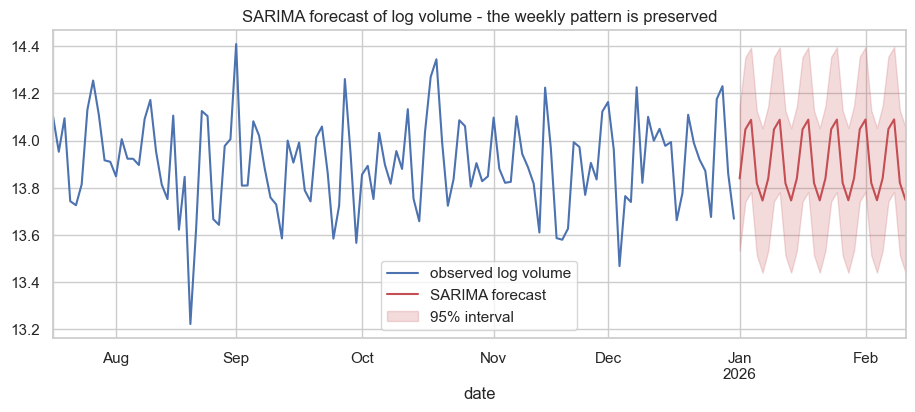

In [10]:
# Forecast the next 30 business days of log volume.
horizon = 30
forecast = sarima_model.get_forecast(steps=horizon)
mean_fc = forecast.predicted_mean
ci      = forecast.conf_int(alpha=0.05)

future_dates = pd.bdate_range(log_volume.index[-1] + pd.Timedelta("1D"), periods=horizon)
mean_fc.index = future_dates
ci.index      = future_dates

plt.figure(figsize=(11, 4))
log_volume.iloc[-120:].plot(color="#4C72B0", label="observed log volume")
mean_fc.plot(color="#C44E52", label="SARIMA forecast")
plt.fill_between(future_dates, ci.iloc[:, 0], ci.iloc[:, 1],
                 color="#C44E52", alpha=0.2, label="95% interval")
plt.title("SARIMA forecast of log volume - the weekly pattern is preserved")
plt.legend()
plt.show()


Notice the forecast wiggles up and down with a weekly rhythm - that is the seasonal component of SARIMA in action. A plain ARIMA without the seasonal terms would produce a flat or smoothly-decaying forecast.


## 7. SARIMAX - SARIMA with eXogenous regressors

The "X" stands for *eXogenous*. SARIMAX lets us include external variables that we believe influence the series:

$$
\Phi(L)\, \Phi_s(L^s)\, (1 - L)^d\, (1 - L^s)^D\, y_t
   \;=\; \beta^\top x_t + \Theta(L)\, \Theta_s(L^s)\, \varepsilon_t.
$$

The new term $\beta^\top x_t$ is just a linear regression of $y_t$ on a vector of exogenous variables $x_t$ - the same kind of regression you saw in `LinearRegression.ipynb`, except wrapped inside a SARIMA structure.

Why is this useful for stocks?

- We can use **volume** to help predict **returns** (price moves are often accompanied by volume spikes).
- We can use **RSI** as an additional signal of momentum.
- For real equities, you would also include macro variables: interest rates, news sentiment, etc.

Below we use SMA-20 (level), RSI-14 (momentum), and log-volume as exogenous inputs to forecast log returns.


In [11]:
data = stock.dropna().copy()

y = data["log_return"]
X = data[["sma_20", "rsi_14"]].copy()
X["log_volume"] = np.log(data["volume"])

# Chronological split: train on the first 80%, test on the last 20%.
split = int(0.8 * len(data))
y_train, y_test = y.iloc[:split], y.iloc[split:]
X_train, X_test = X.iloc[:split], X.iloc[split:]

sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 5),
).fit(disp=False)

print(sarimax_model.summary().tables[1])


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sma_20        -0.0001   9.63e-05     -1.103      0.270      -0.000    8.26e-05
rsi_14         0.0003   6.22e-05      4.620      0.000       0.000       0.000
log_volume    -0.0003      0.001     -0.360      0.719      -0.002       0.001
ar.L1         -0.1240      0.538     -0.230      0.818      -1.179       0.931
ma.L1          0.2070      0.546      0.379      0.705      -0.864       1.278
ar.S.L5        0.0282      0.903      0.031      0.975      -1.742       1.799
ma.S.L5       -0.0915      0.902     -0.101      0.919      -1.860       1.677
sigma2         0.0003   1.96e-05     15.581      0.000       0.000       0.000


/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX out-of-sample MAE on log returns: 0.01501


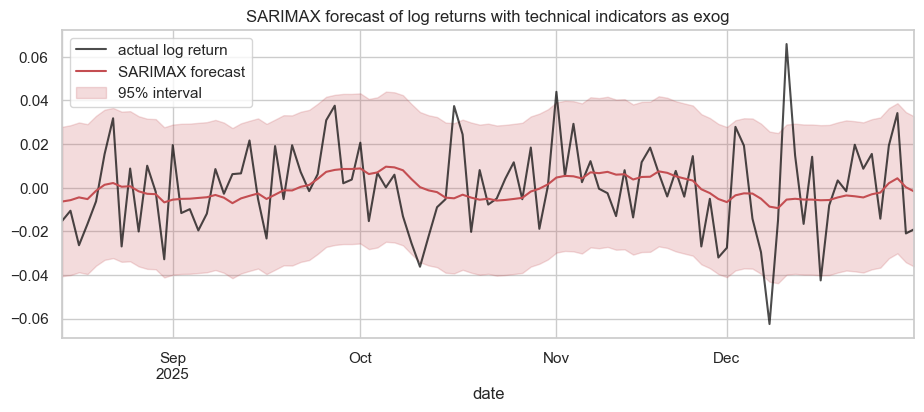

In [12]:
# One-step-ahead forecasts on the test set, using true exog values for X.
pred = sarimax_model.get_forecast(steps=len(y_test), exog=X_test)
pred_mean = pred.predicted_mean
pred_ci   = pred.conf_int(alpha=0.05)

# Mean absolute error.
mae = np.mean(np.abs(y_test.values - pred_mean.values))
print(f"SARIMAX out-of-sample MAE on log returns: {mae:.5f}")

plt.figure(figsize=(11, 4))
y_test.plot(color="black", alpha=0.7, label="actual log return")
pred_mean.plot(color="#C44E52", label="SARIMAX forecast")
plt.fill_between(y_test.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                 color="#C44E52", alpha=0.2, label="95% interval")
plt.title("SARIMAX forecast of log returns with technical indicators as exog")
plt.legend()
plt.show()


A practical note: log returns are notoriously hard to predict on real stocks. Out-of-sample MAE is small mostly because returns themselves are small. The interesting question is whether the model's directional accuracy is better than chance - we leave that as an exercise.

### Walking up the ladder

We have just gone from the simplest building block to a fairly capable model:

1. AR(p) - regress on the past.
2. MA(q) - regress on past errors.
3. ARMA(p, q) - combine them.
4. ARIMA(p, d, q) - difference first, then ARMA.
5. SARIMA(p, d, q)(P, D, Q, s) - add seasonal AR, I, and MA.
6. SARIMAX - add exogenous regressors.

Almost every classical time-series problem in finance, retail, energy, and operations is solved with some member of this family.


## 8. Neural forecasting - N-BEATS

N-BEATS (*Neural Basis Expansion Analysis for Time Series*, Oreshkin et al., 2019) is a feed-forward neural network for time-series forecasting. It is interesting for two reasons:

1. It does not use convolutions or recurrence - just simple fully-connected blocks.
2. It is *interpretable*: it explicitly decomposes the forecast into a trend block and a seasonality block.

### 8.1 The basic block

Given a window of the last $L$ observations $\mathbf{x} \in \mathbb{R}^L$, a single block produces two outputs:

- A **backcast** $\hat{\mathbf{x}}$ that tries to reconstruct the input window.
- A **forecast** $\hat{\mathbf{y}}$ for the next $H$ steps.

Internally:

$$
\mathbf{h} = \text{FC}_4 \circ \text{FC}_3 \circ \text{FC}_2 \circ \text{FC}_1 (\mathbf{x}),
$$

$$
\theta^{\text{back}} = W_b\, \mathbf{h}, \qquad \theta^{\text{fore}} = W_f\, \mathbf{h},
$$

$$
\hat{\mathbf{x}} = g_b(\theta^{\text{back}}), \qquad \hat{\mathbf{y}} = g_f(\theta^{\text{fore}}).
$$

The functions $g_b$ and $g_f$ are **basis expansions**. In the *interpretable* version of N-BEATS, $g$ is a polynomial (for trend) or a Fourier series (for seasonality):

- Trend basis: $\hat{y}_t = \sum_{i=0}^{p} \theta_i\, t^i$.
- Seasonality basis: $\hat{y}_t = \sum_{i=0}^{H/2-1} \theta_i^{(c)} \cos(2\pi i t / H) + \theta_i^{(s)} \sin(2\pi i t / H)$.

### 8.2 Stacking and residuals

Blocks are stacked. Each block subtracts its backcast from the input before passing it on, so later blocks see only what previous blocks failed to explain. The forecasts of all blocks are summed:

$$
\mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} - \hat{\mathbf{x}}^{(k)}, \qquad
\hat{\mathbf{y}}^{\text{total}} = \sum_k \hat{\mathbf{y}}^{(k)}.
$$

This residual structure is what makes N-BEATS interpretable: the trend stack captures slow drift, the seasonality stack captures repeating patterns, and the "generic" stack captures whatever is left.

### 8.3 Training one with `neuralforecast`

The Nixtla `neuralforecast` library wraps all of this in a one-line model definition. It expects the data in **long form** with three required columns:

| Column | Meaning |
|--------|---------|
| `unique_id` | An identifier for the series (since the library can train on many series at once). |
| `ds` | The timestamp. |
| `y` | The value to forecast. |

Below we reshape our log-volume series into that format and train an N-BEATS model with a forecast horizon of 30 business days. We use a small `max_steps` so it trains in seconds rather than minutes - in production you would use several thousand steps.

In [13]:
# Reshape log_volume into the long-form (unique_id, ds, y) layout that Nixtla expects.
H = 30  # forecast horizon (business days)

nf_df = pd.DataFrame({
    "unique_id": "VOL",                         # one series, called VOL
    "ds":        log_volume.index,
    "y":         log_volume.values,
})

train_df = nf_df.iloc[:-H]
test_df  = nf_df.iloc[-H:]

print(train_df.head())
print(f"\nTraining rows: {len(train_df)}    Test rows: {len(test_df)}")

  unique_id         ds          y
0       VOL 2024-01-01  14.200597
1       VOL 2024-01-02  13.752318
2       VOL 2024-01-03  13.966875
3       VOL 2024-01-04  13.737001
4       VOL 2024-01-05  14.222556

Training rows: 493    Test rows: 30


In [14]:
# Train an N-BEATS model. The `freq="B"` argument tells Nixtla we are using business days.
# `input_size` is the look-back window length the model gets to see.
nbeats_model = NBEATS(
    h=H,
    input_size=3 * H,        # look back 90 business days
    max_steps=200,           # small; bump up to a few thousand for real use
    val_check_steps=200,
    scaler_type="standard",
    random_seed=42,
)

nf = NeuralForecast(models=[nbeats_model], freq="B")
nf.fit(df=train_df)

nbeats_fc = nf.predict()
print(nbeats_fc.head())

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.6 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.6 M                                                                                            
Non-trainable params: 7.3 K                                                                                        
Total params: 2.6 M                                                                                                
Total estimated model params size (MB): 10                                                                         
Modules in train mode: 31                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=200` reached.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  unique_id         ds     NBEATS
0       VOL 2025-11-20  13.901414
1       VOL 2025-11-21  13.913710
2       VOL 2025-11-24  14.035612
3       VOL 2025-11-25  13.761031
4       VOL 2025-11-26  13.759041


N-BEATS out-of-sample MAE on log volume: 0.1421


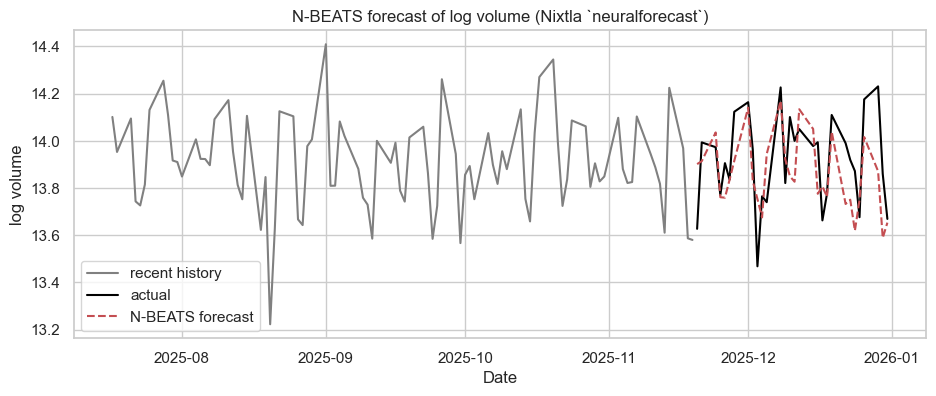

In [15]:
# Compare the N-BEATS forecast to the actual held-out values.
mae_nbeats = np.mean(np.abs(test_df["y"].values - nbeats_fc["NBEATS"].values))
print(f"N-BEATS out-of-sample MAE on log volume: {mae_nbeats:.4f}")

plt.figure(figsize=(11, 4))
plt.plot(train_df["ds"].iloc[-3*H:], train_df["y"].iloc[-3*H:], color="grey",
         label="recent history")
plt.plot(test_df["ds"], test_df["y"], color="black", label="actual")
plt.plot(nbeats_fc["ds"], nbeats_fc["NBEATS"], "--", color="#C44E52",
         label="N-BEATS forecast")
plt.title("N-BEATS forecast of log volume (Nixtla `neuralforecast`)")
plt.xlabel("Date"); plt.ylabel("log volume")
plt.legend()
plt.show()

N-BEATS picks up the weekly rhythm and tracks the level reasonably well even with very limited training. Three things to try yourself:

- Bump `max_steps` up to a few thousand. Quality usually improves smoothly with training.
- Swap `NBEATS` for `NHITS` (also from `neuralforecast.models`) - it is the next-generation cousin of N-BEATS that handles long horizons better.
- Train on multiple stocks at once by stacking them in the same long-form DataFrame, each with its own `unique_id`. The same `nf.fit()` call handles many series in parallel - this is the practical superpower of cross-series neural forecasting.

## 9. The Temporal Fusion Transformer (TFT)

TFT (Lim et al., 2021) was designed for **multi-horizon, multi-input** forecasting where you have a mix of:

- *Past observations* of the target series (e.g. price history).
- *Past covariates* whose values you observed (e.g. realised volume, RSI).
- *Known future inputs* (calendar features, scheduled events).
- *Static covariates* (which stock, which store, which country).

### 9.1 Building blocks

The TFT pipeline can be summarised in five stages:

1. **Variable-selection networks.** A small gated network at each time step decides which of the many input variables to weight up or down. This is how TFT achieves feature importance.
2. **Static covariate encoders.** Static features (e.g. "ticker symbol") are encoded once and used to *condition* every other component.
3. **Local processing with an LSTM.** A sequence-to-sequence LSTM gives a strong baseline for short-term temporal patterns.
4. **Multi-head attention over time.** A transformer head looks at the entire history at once. Crucially, the attention weights are **interpretable** - you can read off which past time steps mattered most for each forecast.
5. **Quantile output head.** Instead of producing a single number, TFT predicts several quantiles ($q_{0.1}, q_{0.5}, q_{0.9}$, etc.) so you get a forecast distribution. The training loss is the **pinball loss**:

$$
\mathcal{L}_q(y, \hat{y}) = \begin{cases} q\, (y - \hat{y}) & \text{if } y \geq \hat{y}, \\ (1 - q)(\hat{y} - y) & \text{if } y < \hat{y}. \end{cases}
$$

Pinball loss is what allows a single network to be trained to predict any quantile, including the median (q = 0.5).

### 9.2 Training a TFT with `neuralforecast`

Just like N-BEATS, the Nixtla wrapper hides almost all of the architectural complexity. The interesting choice we make here is the loss: `MQLoss(level=[80, 90])` asks the model to predict three quantiles - the median and the lower/upper bounds of 80% and 90% prediction intervals - using pinball loss for each.

In [16]:
# Forecast log returns with a TFT, asking for 80% and 90% prediction intervals.
returns_long = pd.DataFrame({
    "unique_id": "RET",
    "ds":        stock["log_return"].index,
    "y":         stock["log_return"].values,
})

H_ret  = 30
ret_train = returns_long.iloc[:-H_ret]
ret_test  = returns_long.iloc[-H_ret:]

tft_model = TFT(
    h=H_ret,
    input_size=4 * H_ret,
    loss=MQLoss(level=[80, 90]),     # pinball loss for the median + 80% + 90% intervals
    max_steps=200,
    val_check_steps=200,
    scaler_type="standard",
    random_seed=42,
)

nf_tft = NeuralForecast(models=[tft_model], freq="B")
nf_tft.fit(df=ret_train)

tft_fc = nf_tft.predict()
print(tft_fc.head())
print("\nQuantile columns produced by TFT:", [c for c in tft_fc.columns if c.startswith("TFT")])

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss                    │ MQLoss                   │      5 │ train │     0 │
│ 1 │ padder_train            │ ConstantPad1d            │      0 │ train │     0 │
│ 2 │ scaler                  │ TemporalNorm             │      0 │ train │     0 │
│ 3 │ embedding               │ TFTEmbedding             │    512 │ train │     0 │
│ 4 │ temporal_encoder        │ TemporalCovariateEncoder │  613 K │ train │     0 │
│ 5 │ temporal_fusion_decoder │ TemporalFusionDecoder    │  256 K │ train │     0 │
│ 6 │ output_adapter          │ Linear                   │    645 │ train │     0 │
└───┴─────────────────────────┴──────────────────────────┴────────┴───────┴───────┘

Trainable params: 870 K                                                                                            
Non-trainable params: 5                                                                                            
Total params: 870 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 88                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_steps=200` reached.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


  unique_id         ds  TFT-median  TFT-lo-90  TFT-lo-80  TFT-hi-80  TFT-hi-90
0       RET 2025-11-20    0.001595  -0.025177  -0.022354   0.028162   0.034207
1       RET 2025-11-21   -0.000991  -0.027397  -0.024017   0.026000   0.033592
2       RET 2025-11-24   -0.002093  -0.028847  -0.024570   0.024702   0.032879
3       RET 2025-11-25   -0.002773  -0.029817  -0.024708   0.023822   0.032110
4       RET 2025-11-26   -0.003079  -0.030565  -0.024800   0.023357   0.031579

Quantile columns produced by TFT: ['TFT-median', 'TFT-lo-90', 'TFT-lo-80', 'TFT-hi-80', 'TFT-hi-90']


### 9.3 Reading the TFT output

Notice the difference compared to ARIMA: the model produces a **forecast distribution**, not a single number. The 80% and 90% intervals widen with the horizon, which is exactly what we want a quantile forecast to do.

Practical note: in finance, the gap between the 0.1 and 0.9 quantiles is usually a more useful number than the median. It tells you the range your portfolio should be prepared for, not just the most likely outcome.

What we did *not* do here that would help on real data:

- Pass past covariates with `hist_exog_list=["volume", "rsi_14"]`. Each row of the long-form DataFrame would carry those extra columns.
- Pass static metadata like a ticker symbol with `static_features`.
- Train across many series at once - TFT really shines when it can learn shared structure across hundreds or thousands of related series.

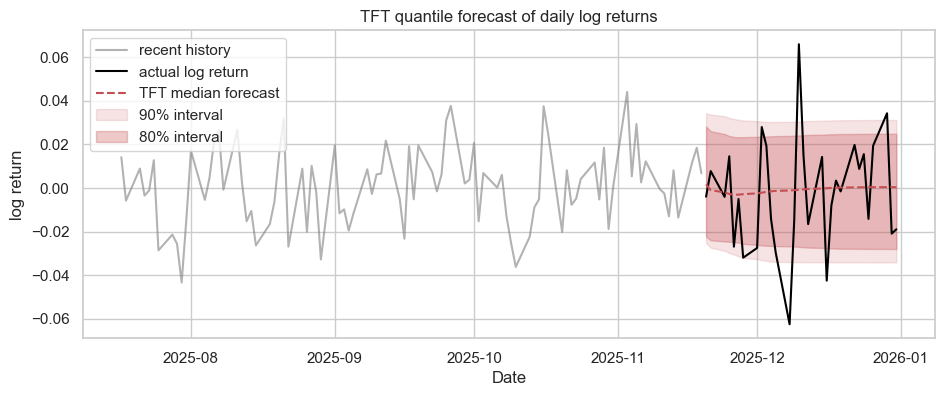

TFT median MAE on log returns: 0.02000


In [17]:
# Plot the TFT median plus the 80% and 90% prediction intervals.
median_col = "TFT-median"
lo80_col = "TFT-lo-80";  hi80_col = "TFT-hi-80"
lo90_col = "TFT-lo-90";  hi90_col = "TFT-hi-90"

plt.figure(figsize=(11, 4))
plt.plot(ret_train["ds"].iloc[-3*H_ret:], ret_train["y"].iloc[-3*H_ret:],
         color="grey", alpha=0.6, label="recent history")
plt.plot(ret_test["ds"], ret_test["y"], color="black", label="actual log return")
plt.plot(tft_fc["ds"], tft_fc[median_col], "--", color="#C44E52",
         label="TFT median forecast")
plt.fill_between(tft_fc["ds"], tft_fc[lo90_col], tft_fc[hi90_col],
                 alpha=0.15, color="#C44E52", label="90% interval")
plt.fill_between(tft_fc["ds"], tft_fc[lo80_col], tft_fc[hi80_col],
                 alpha=0.30, color="#C44E52", label="80% interval")
plt.title("TFT quantile forecast of daily log returns")
plt.xlabel("Date"); plt.ylabel("log return")
plt.legend()
plt.show()

mae_tft = np.mean(np.abs(ret_test["y"].values - tft_fc[median_col].values))
print(f"TFT median MAE on log returns: {mae_tft:.5f}")

## 10. Hierarchical forecasting

So far we have forecast a single series at a time. In reality, time-series problems often come with a **hierarchy**:

```
                   Total
                    /  \
                Equity   Bonds
                /  \      /  \
            Tech  Bank  Govt Corp
```

Each level is the sum of the level below it. We want all levels to be forecast well, *and* we want the forecasts at different levels to be **coherent** - the forecast of "Total" should equal the sum of the forecasts of "Tech", "Bank", "Govt", and "Corp". If we forecast each level independently, that almost never holds.

The standard fix is **reconciliation**: we forecast every level independently, then adjust them so that they add up.

### 10.1 The summing matrix

If there are $m$ bottom-level series (the leaves) and $n$ total series including all aggregates, we collect every level into a single vector $\mathbf{y}_t \in \mathbb{R}^n$. The aggregation can be written

$$
\mathbf{y}_t = S\, \mathbf{b}_t,
$$

where $\mathbf{b}_t \in \mathbb{R}^m$ is the bottom level and $S \in \{0, 1\}^{n \times m}$ is the **summing matrix** that adds up the right rows.

### 10.2 Reconciliation methods

Given independent base forecasts $\hat{\mathbf{y}}_t$ at every level, the reconciled forecast is

$$
\tilde{\mathbf{y}}_t = S\, P\, \hat{\mathbf{y}}_t,
$$

for some projection matrix $P$. Choices of $P$ correspond to different methods:

| Method | What it does |
|--------|--------------|
| Bottom-up | Use only the leaf forecasts; sum them up to get every aggregate. |
| Top-down | Use the top forecast; split it according to historical proportions. |
| OLS / MinT | Use information from all levels and combine them optimally. |

### 10.3 Doing it with `hierarchicalforecast`

The Nixtla `hierarchicalforecast` package automates the whole pipeline:

1. Build a long-form DataFrame of leaf-level series.
2. `aggregate(...)` constructs the aggregated series and the summing matrix `S` for you.
3. Use `StatsForecast` (or any other forecaster) to get base forecasts at every level.
4. `HierarchicalReconciliation(reconcilers=[...])` reconciles them into coherent forecasts in one call.

We will build a small two-level hierarchy: `total = tech + bank`, where `tech = tech_a + tech_b` and `bank = bank_a + bank_b`.

In [18]:
# Build four leaf-level series by perturbing our synthetic stock series.
n = len(stock)
leaf_data = pd.DataFrame({
    "tech_a": stock["close"].values * (1 + 0.02 * rng.standard_normal(n).cumsum() / np.sqrt(n)),
    "tech_b": stock["close"].values * (1 + 0.02 * rng.standard_normal(n).cumsum() / np.sqrt(n)),
    "bank_a": stock["close"].values * 0.7 * (1 + 0.02 * rng.standard_normal(n).cumsum() / np.sqrt(n)),
    "bank_b": stock["close"].values * 0.7 * (1 + 0.02 * rng.standard_normal(n).cumsum() / np.sqrt(n)),
}, index=stock.index)

# Reshape to long form, with a `sector` column that encodes the hierarchy.
long_rows = []
for col in leaf_data.columns:
    sector = "tech" if col.startswith("tech") else "bank"
    long_rows.append(pd.DataFrame({
        "sector": sector,
        "stock":  col,
        "ds":     leaf_data.index,
        "y":      leaf_data[col].values,
    }))
leaves_long = pd.concat(long_rows, ignore_index=True)
print(leaves_long.head())
print(f"\nTotal rows: {len(leaves_long)}  (4 stocks x {n} days)")

  sector   stock         ds           y
0   tech  tech_a 2024-01-01   99.984832
1   tech  tech_a 2024-01-02  100.362041
2   tech  tech_a 2024-01-03   99.230994
3   tech  tech_a 2024-01-04  100.142984
4   tech  tech_a 2024-01-05  101.447808

Total rows: 2092  (4 stocks x 523 days)


In [19]:
# `aggregate` builds (1) the long-form DataFrame at every hierarchy level,
# (2) the summing matrix S, and (3) a tags dictionary that names each level.
spec = [
    ["sector"],            # level 1: sector totals (tech, bank)
    ["sector", "stock"],   # level 2: leaf stocks
]
Y_df, S_df, tags = aggregate(df=leaves_long, spec=spec)

print("Hierarchy levels and their series:")
for level, ids in tags.items():
    print(f"  {level:14s} ->  {list(ids)}")

print("\nSumming matrix S (rows = series in hierarchy, columns = leaves):")
print(S_df)

Hierarchy levels and their series:
  sector         ->  ['bank', 'tech']
  sector/stock   ->  ['bank/bank_a', 'bank/bank_b', 'tech/tech_a', 'tech/tech_b']

Summing matrix S (rows = series in hierarchy, columns = leaves):
     unique_id  bank/bank_a  bank/bank_b  tech/tech_a  tech/tech_b
0         bank          1.0          1.0          0.0          0.0
1         tech          0.0          0.0          1.0          1.0
2  bank/bank_a          1.0          0.0          0.0          0.0
3  bank/bank_b          0.0          1.0          0.0          0.0
4  tech/tech_a          0.0          0.0          1.0          0.0
5  tech/tech_b          0.0          0.0          0.0          1.0


In [20]:
# Step 1: produce independent base forecasts for every series in the hierarchy
# using `statsforecast` with AutoARIMA. We hold back the last 30 business days as test.
H_h = 30
Y_train = Y_df.groupby("unique_id", group_keys=False).apply(lambda g: g.iloc[:-H_h])
Y_test  = Y_df.groupby("unique_id", group_keys=False).apply(lambda g: g.iloc[-H_h:])

sf = StatsForecast(
    models=[AutoARIMA(season_length=5)],
    freq="B",
    n_jobs=1,
)
base_fc = sf.forecast(df=Y_train, h=H_h)
print(base_fc.head())
print(f"\nBase forecast rows: {len(base_fc)}  (= {len(tags)+1} levels with their series x {H_h} days, more or less)")

  unique_id         ds   AutoARIMA
0      bank 2025-11-20  176.554823
1      bank 2025-11-21  176.554823
2      bank 2025-11-24  176.554823
3      bank 2025-11-25  176.554823
4      bank 2025-11-26  176.554823

Base forecast rows: 180  (= 3 levels with their series x 30 days, more or less)


In [22]:
# Step 2: reconcile the base forecasts so they are coherent across levels.
# We compare three reconcilers in one call.
reconcilers = [
    BottomUp(),
    TopDown(method="forecast_proportions"),
    MinTrace(method="ols"),     # the optimal-combination method
]

hrec = HierarchicalReconciliation(reconcilers=reconcilers)
reconciled = hrec.reconcile(
    Y_hat_df=base_fc,
    Y_df=Y_train,
    S_df=S_df,
    tags=tags,
)
print(reconciled.head())

  unique_id         ds   AutoARIMA  AutoARIMA/BottomUp  \
0      bank 2025-11-20  176.554823          176.554811   
1      bank 2025-11-21  176.554823          176.554811   
2      bank 2025-11-24  176.554823          176.554811   
3      bank 2025-11-25  176.554823          176.554811   
4      bank 2025-11-26  176.554823          176.554811   

   AutoARIMA/TopDown_method-forecast_proportions  \
0                                     176.554823   
1                                     176.554823   
2                                     176.554823   
3                                     176.554823   
4                                     176.554823   

   AutoARIMA/MinTrace_method-ols  
0                     176.554819  
1                     176.554819  
2                     176.554819  
3                     176.554819  
4                     176.554819  


In [23]:
# Coherence check on the very first forecast horizon: does total = tech + bank
# under each reconciler?
first_day = reconciled["ds"].min()
day1 = reconciled[reconciled["ds"] == first_day].set_index("unique_id")

print(f"Forecast for {first_day.date()}:\n")
for col in ["AutoARIMA", "AutoARIMA/BottomUp",
            "AutoARIMA/TopDown_method-forecast_proportions",
            "AutoARIMA/MinTrace_method-ols"]:
    label = col.split("/", 1)[-1] if "/" in col else "base (un-reconciled)"
    total = day1.loc["sector/stock"][col] if "sector/stock" in day1.index else None
    tech  = day1.loc["tech"][col]   if "tech"   in day1.index else None
    bank  = day1.loc["bank"][col]   if "bank"   in day1.index else None
    leaves_sum = (day1.loc["tech/tech_a"][col] + day1.loc["tech/tech_b"][col]
                 + day1.loc["bank/bank_a"][col] + day1.loc["bank/bank_b"][col])
    print(f"  {label}")
    print(f"    tech            = {tech:.2f}")
    print(f"    bank            = {bank:.2f}")
    print(f"    sum of 4 leaves = {leaves_sum:.2f}")
    print(f"    tech + bank     = {tech + bank:.2f}    "
          f"(should equal sum of leaves under bottom-up / MinT)")
    print()

Forecast for 2025-11-20:

  base (un-reconciled)
    tech            = 239.62
    bank            = 176.55
    sum of 4 leaves = 416.17
    tech + bank     = 416.17    (should equal sum of leaves under bottom-up / MinT)

  BottomUp
    tech            = 239.62
    bank            = 176.55
    sum of 4 leaves = 416.17
    tech + bank     = 416.17    (should equal sum of leaves under bottom-up / MinT)

  TopDown_method-forecast_proportions
    tech            = 239.62
    bank            = 176.55
    sum of 4 leaves = 416.17
    tech + bank     = 416.17    (should equal sum of leaves under bottom-up / MinT)

  MinTrace_method-ols
    tech            = 239.62
    bank            = 176.55
    sum of 4 leaves = 416.17
    tech + bank     = 416.17    (should equal sum of leaves under bottom-up / MinT)



After reconciliation, "tech + bank" matches the sum of all four leaf forecasts under both bottom-up and MinT - the hierarchy is now coherent. The base AutoARIMA forecasts on their own would not satisfy this, because each was fit independently.

The choice between methods is a question of where you trust your data most:

- **Bottom-up** (`BottomUp`) is the right choice when leaf-level data is reliable.
- **Top-down** (`TopDown(method="forecast_proportions")`) works when only the aggregate is well-measured.
- **OLS / MinT** (`MinTrace(method="ols" | "wls_struct" | "wls_var" | "mint_shrink" | "mint_cov")`) combines information from every level using a covariance estimate of the base forecast errors. It is usually the best default in production.

In real portfolio management, hierarchical reconciliation is what keeps "predicted total revenue" equal to "predicted revenue per region summed up", which auditors and finance teams care about deeply. The Nixtla `hierarchicalforecast` library makes the whole pipeline a few lines of code regardless of how deep your hierarchy is.

## 11. Summary

In this notebook we covered the main families of time-series models, with simplified mathematics and a running stock-style example.

| Model | Captures | How we ran it |
|-------|----------|----------------|
| AR(p) | Persistence in the value | Simulated by hand, ACF/PACF in `statsmodels`. |
| MA(q) | Lingering effect of past shocks | Simulated by hand. |
| ARMA(p, q) | Both | Special case of `statsmodels.tsa.arima.ARIMA`. |
| ARIMA(p, d, q) | Trend (via differencing) + ARMA | `statsmodels.tsa.arima.ARIMA`. |
| SARIMA | Trend + seasonality | `statsmodels.tsa.statespace.SARIMAX`. |
| SARIMAX | All of the above + exogenous regressors | `statsmodels.tsa.statespace.SARIMAX` with `exog`. |
| N-BEATS | Trend + seasonality via neural basis blocks | `neuralforecast.NBEATS`. |
| TFT | Multi-input, multi-horizon, quantile output | `neuralforecast.TFT` with `MQLoss`. |
| Hierarchical reconciliation | Coherence across levels | `hierarchicalforecast` with `BottomUp`, `TopDown`, `MinTrace`. |

A few practical lessons:

- Start simple. ARIMA or SARIMA solves a surprising number of real problems.
- Always check residual diagnostics; a model is only as good as its residuals.
- Use a chronological train/test split. Never shuffle a time series.
- The Nixtla long-form data convention (`unique_id`, `ds`, `y`) is the same across `statsforecast`, `neuralforecast`, and `hierarchicalforecast`. Once you learn it, swapping models is almost trivial.
- For neural models, you usually need many series, not just one - feed them all in one DataFrame and let the model share parameters.
- For aggregated forecasts, reconcile. Stakeholders care about coherence.

### Suggested next steps

- Apply this notebook to a real dataset: download daily OHLCV data for a stock or index from a public source and recompute the indicators. The Nixtla data layout makes this almost a copy-paste exercise.
- Try `AutoARIMA`, `AutoETS`, and `AutoTheta` from `statsforecast` as a fast classical baseline before reaching for neural models.
- Swap `NBEATS` for `NHITS` or `PatchTST` from `neuralforecast` and see if it improves accuracy.
- Read the original papers - they are short and surprisingly readable:
  - Box and Jenkins (1970) for ARIMA.
  - Oreshkin et al. (2019) for N-BEATS.
  - Lim et al. (2021) for TFT.
  - Hyndman et al. (2011) for hierarchical reconciliation.
- Browse the Nixtla documentation at <https://nixtlaverse.nixtla.io>; the tutorials there cover everything we touched on here, with real datasets.